## <div align="center"> UJIAN TENGAH SEMESTER IF540-L MACHINE LEARNING </div>
## <div align="center"> Semester Gasal 2024/2025 </div>
## <div align="center"> Deteksi Penyakit Ginjal Kronis Berdasarkan Parameter Klinis Dengan Algoritma Random Forest </div>

---
### Kelompok - 8

#### Anggota Kelompok : 
1. Friedrich Litani Santoso - 00000068855
2. Farrelius Kevin - 00000081783
3. Merhandes Gunawan - 00000081070
4. Marcellus Eugene Kaparang - 00000082420
5. Genadi Ikhsan Jaya - 00000080773

...

---

### Dataset yang digunakan untuk projek:

1. [Chronic_Kidney_Disease] – sumber : [https://www.kaggle.com/datasets/rabieelkharoua/chronic-kidney-disease-dataset-analysis]

### Hasil kerja

#### Import Library Yang Dibutuhkan

In [3]:
import	pandas	as	pd
import	matplotlib.pyplot as plt
import	seaborn	as	sns
import numpy as np

#### Membaca dan Menampilkan Baris Data sebanyak 5 teratas

In [4]:
data =	pd.read_csv("/Users/marcelluseugene/Downloads/Chronic_Kidney_Disease.csv")
data.head()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,...,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,...,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,...,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,...,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,...,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


#### Menampilkan Total Jumlah Kolom dan Baris

In [5]:
data.shape

(1659, 54)

##### <u>Penjelasan :</u>

Dari output yang dikeluarkan dapat diketahui bahwa dataset Chronic Kidney Disease Data memiliki
- Jumlah Baris sebanyak 1659

- Jumlah Kolom sebanyak 54

---

#### Menampilkan Data dari semua kolom



In [6]:
data.info

<bound method DataFrame.info of       PatientID  Age  Gender  Ethnicity  SocioeconomicStatus  EducationLevel  \
0             1   71       0          0                    0               2   
1             2   34       0          0                    1               3   
2             3   80       1          1                    0               1   
3             4   40       0          2                    0               1   
4             5   43       0          1                    1               2   
...         ...  ...     ...        ...                  ...             ...   
1654       1655   90       0          0                    1               2   
1655       1656   34       0          0                    2               1   
1656       1657   84       0          0                    2               3   
1657       1658   90       0          0                    2               2   
1658       1659   34       1          1                    0               0   

       



---

#### Menampilkan jumlah data yang kosong

In [7]:
data.isnull().sum()

PatientID                        0
Age                              0
Gender                           0
Ethnicity                        0
SocioeconomicStatus              0
EducationLevel                   0
BMI                              0
Smoking                          0
AlcoholConsumption               0
PhysicalActivity                 0
DietQuality                      0
SleepQuality                     0
FamilyHistoryKidneyDisease       0
FamilyHistoryHypertension        0
FamilyHistoryDiabetes            0
PreviousAcuteKidneyInjury        0
UrinaryTractInfections           0
SystolicBP                       0
DiastolicBP                      0
FastingBloodSugar                0
HbA1c                            0
SerumCreatinine                  0
BUNLevels                        0
GFR                              0
ProteinInUrine                   0
ACR                              0
SerumElectrolytesSodium          0
SerumElectrolytesPotassium       0
SerumElectrolytesCal

##### <u>Penjelasan</u>

Dari output diatas, didapatkan informasi bahwa value data yang ada didalam dataset ini tidak ada yang kosong

---

#### Korelasi antar semua fitur didataset

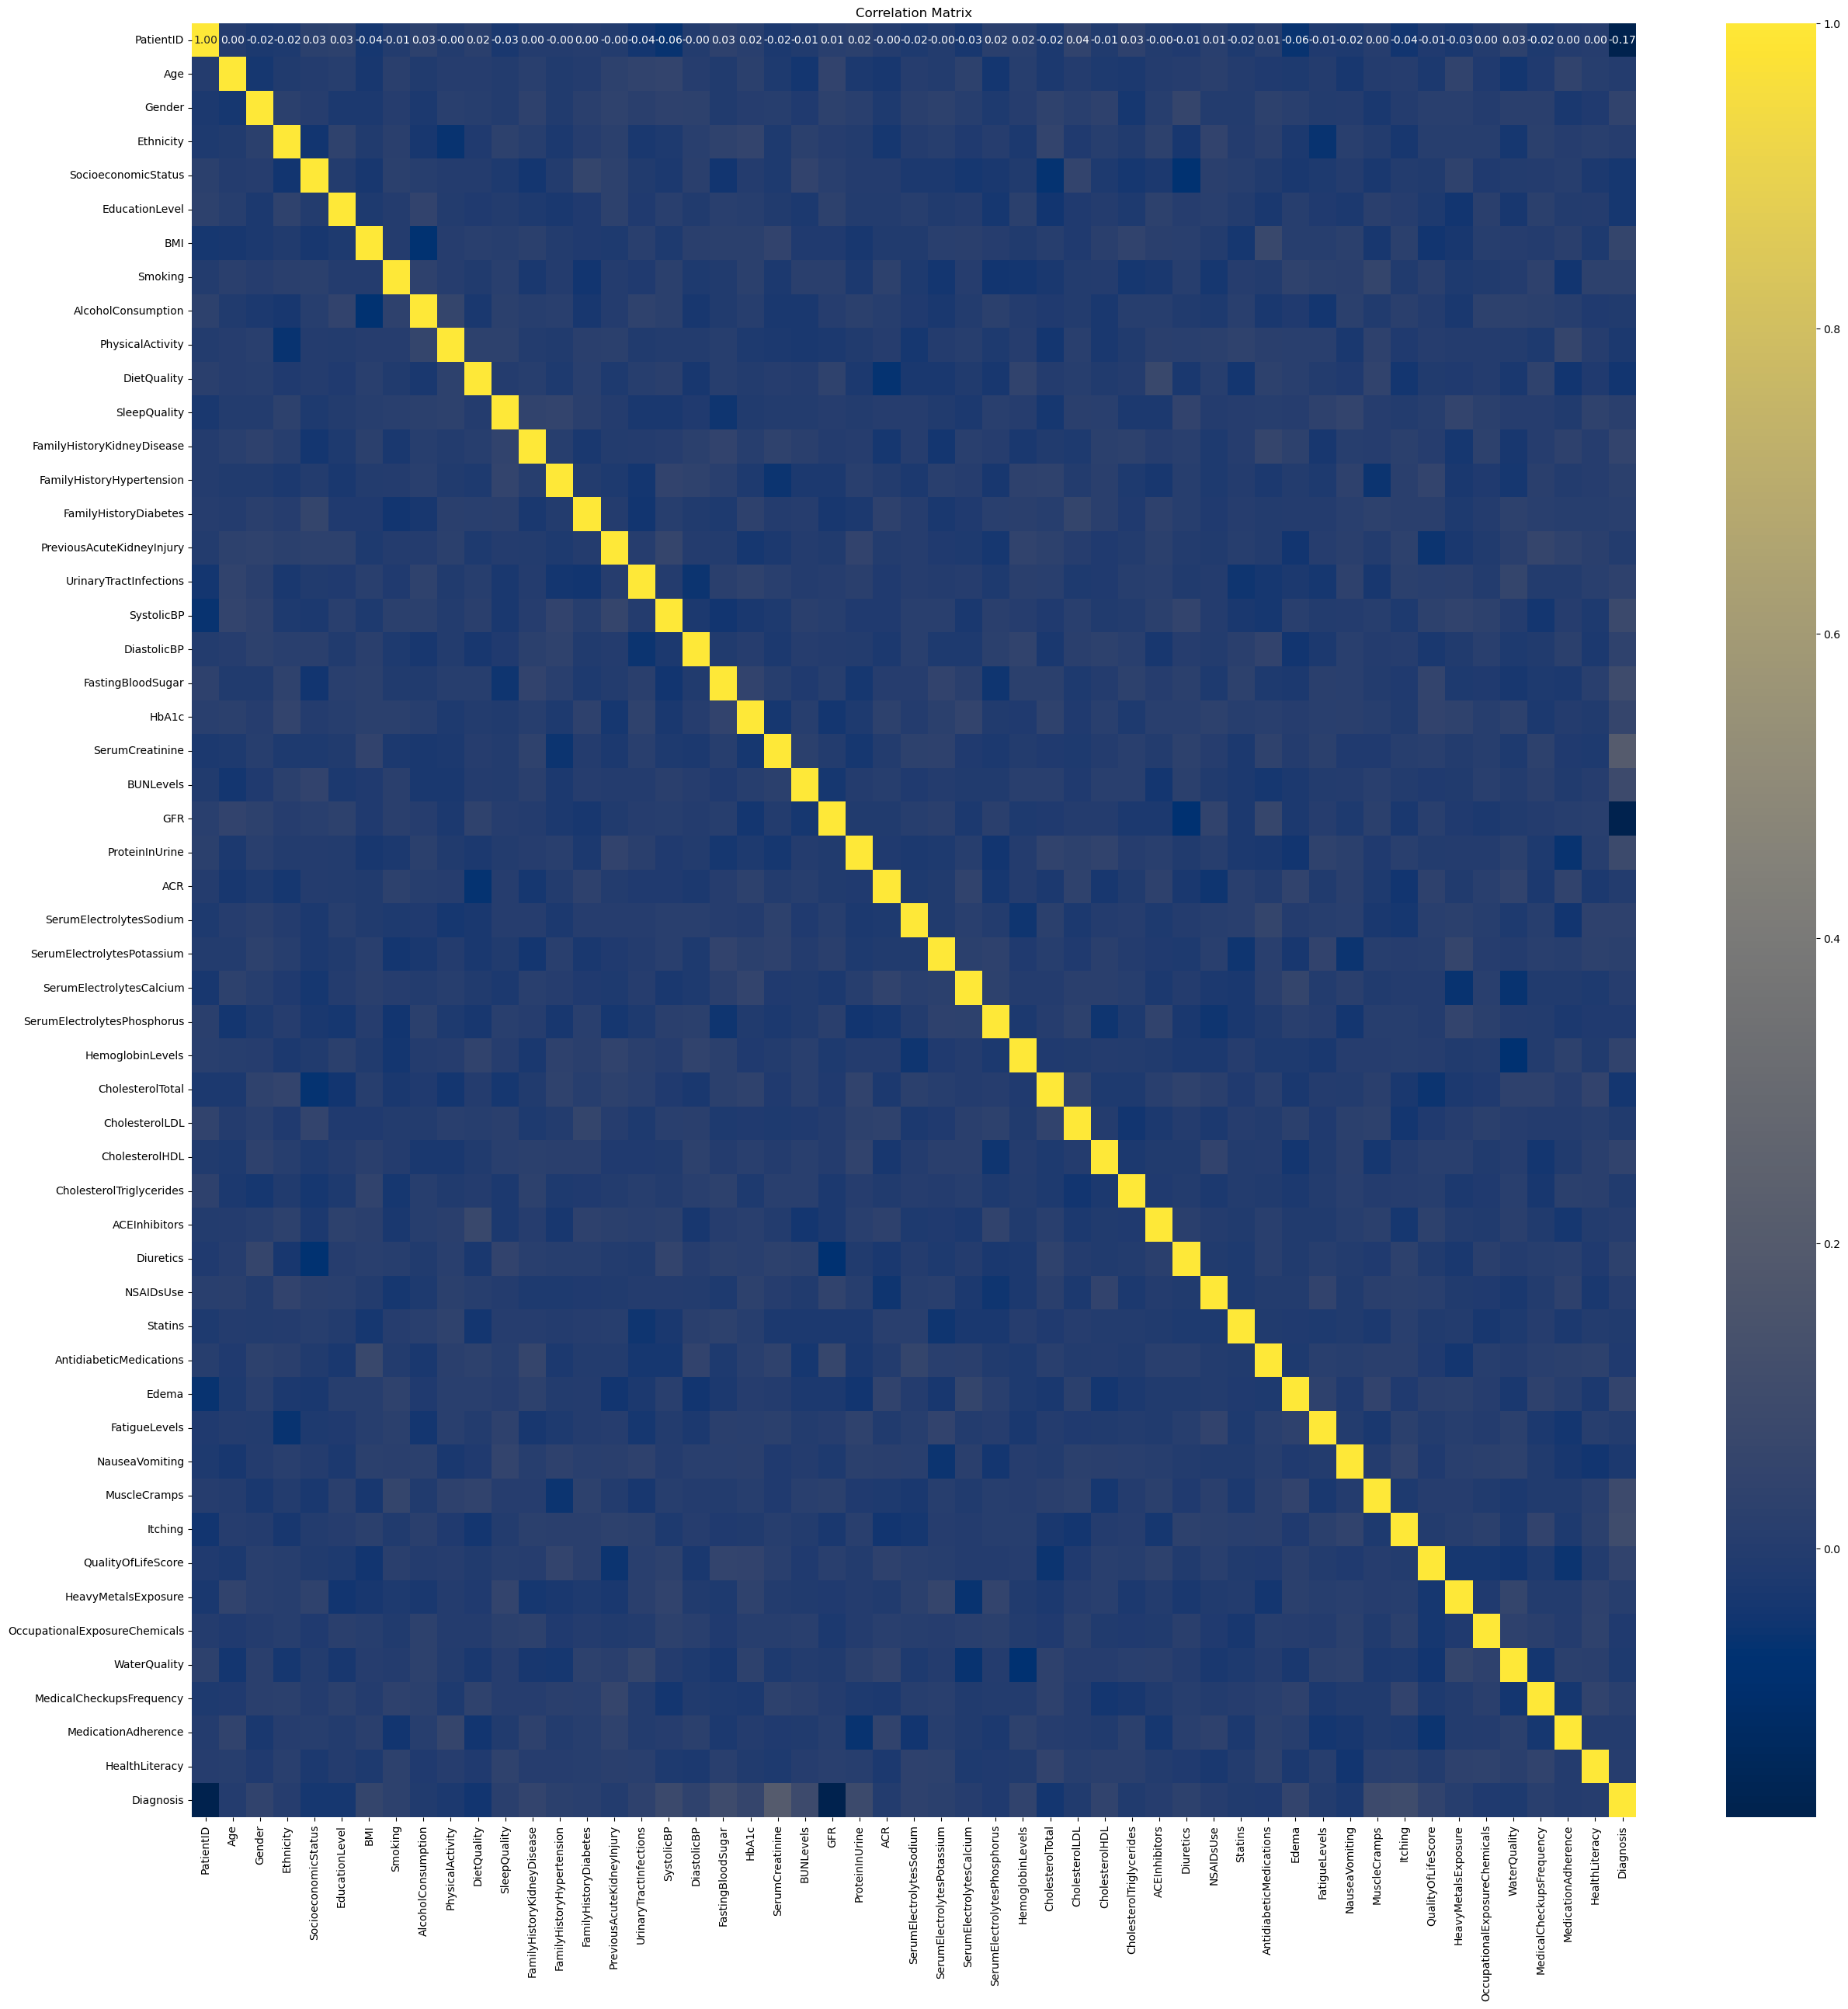

In [8]:
# Memilih hanya kolom numerik dari dataset
numeric_data = data.select_dtypes(include=[np.number])

# Menghitung matriks korelasi
correlation_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(30, 30))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='cividis')
plt.title('Correlation Matrix')
plt.show()

##### <u>Penjelasan</u>

Dari output visual diatas, kita bisa melihat korelasi antar fitur.

- Dari visual diatas dapat dilihat bahwa angka terbesar yang kotak berwarna kuning menandakan memiliki korelasi terkuat yaitu 1.00. Mengapa bisa 1.00 karena korelasi yang dihubungkan memiliki fitur yang sama satu sama lain sehingga menghasilkan korelasi terkuat.

- Korelasi yang kuat antar fitur selain yang kotak berwarna kuning atau berangka 1.00, berada pada antara fitur Diagnosis dan SerumCreatinine dengan angka korelasi mencapai 0.20, disusul dengan antara fitur Diagnosis dan Iching dengan angka korelasi mencapai 0.10, serta antara fitur Diagnosis dan MuscleCramps dengan angka korelasi mencapai 0.09. Korelasi yang kuat antar fitur dapat dilihat dari kotak warna nya yang semakin terang dimana warna yang paling terang yaitu kuning menandakan korelasi terkuat, dibawahnya ada warna abu-abu muda.

- Korelasi yang lemah antar fitur berada pada antara fitur GFR dan Diagnosis dengan angka korelasi yang sangat rendah yaitu -0.18 dan kotak berwarna paling gelap yaitu biru tua, disusul dengan antara fitur Patient ID dan Diagnosis dengan angka korelasi -0.17 yang kotak berwarna biru tua juga


---

#### Drop fitur/kolom yang tidak digunakan

In [9]:
columns_to_drop = [
    "PatientID", "SocioeconomicStatus",
    "EducationLevel", "Smoking", "AlcoholConsumption",
    "PhysicalActivity", "DietQuality", "SleepQuality", 
    "FamilyHistoryKidneyDisease", "FamilyHistoryHypertension", 
    "FamilyHistoryDiabetes", "PreviousAcuteKidneyInjury", 
    "UrinaryTractInfections", "SystolicBP", "DiastolicBP", 
    "FastingBloodSugar", "HbA1c", "CholesterolTotal", 
    "CholesterolLDL", "CholesterolHDL", "CholesterolTriglycerides", 
    "ACEInhibitors", "Diuretics", "NSAIDsUse", "Statins", 
    "AntidiabeticMedications", "Edema", "FatigueLevels", 
    "NauseaVomiting", "MuscleCramps", "Itching", "QualityOfLifeScore", 
    "HeavyMetalsExposure", "OccupationalExposureChemicals", 
    "WaterQuality", "MedicalCheckupsFrequency", "MedicationAdherence", 
    "HealthLiteracy", "DoctorInCharge"
]

data = data.drop(columns=columns_to_drop)
data.head()

,Age,Gender,Ethnicity,BMI,SerumCreatinine,BUNLevels,GFR,ProteinInUrine,ACR,SerumElectrolytesSodium,SerumElectrolytesPotassium,SerumElectrolytesCalcium,SerumElectrolytesPhosphorus,HemoglobinLevels,Diagnosis
0,71,0,0,31.069414,4.962531,25.605949,45.703204,0.744980,123.849426,137.652501,3.626058,10.314420,3.152648,16.114679,1
1,34,0,0,29.692119,3.156799,31.338166,55.784504,3.052317,88.539095,138.141335,5.332871,9.604196,2.855443,15.349205,1
2,80,1,1,37.394822,3.698236,39.738169,67.559032,1.157839,21.170892,142.970116,4.330891,9.885786,4.353513,13.018834,1
3,40,0,2,31.329680,2.868468,21.980958,33.202542,3.745871,123.779699,137.106913,3.810741,9.995894,4.016134,15.056339,1
4,43,0,1,23.726311,3.964877,12.216366,56.319082,2.570993,184.852046,140.627812,4.866765,8.907622,3.947907,16.690561,1


##### <u>Penjelasan</u>

Mengapa fitur - fitur / kolom tersebut didrop:
1. "PatientID" = hanya jumlah pasien dari 1-1659
2. "SocioeconomicStatus" = hanya indikator economi
3. "EducationLevel" = hanya indikator pendidikan pasien
4. "Smoking" = lebih digunakan untuk mendeteksi penyakit paru2
5. "AlcoholConsumption",
6. "PhysicalActivity",
7. "DietQuality", 
8. "SleepQuality", 
9. "FamilyHistoryKidneyDisease", 
10. "FamilyHistoryHypertension", 
11. "FamilyHistoryDiabetes", 
12. "PreviousAcuteKidneyInjury", 
13. "UrinaryTractInfections", 
14. "SystolicBP", 
15. "DiastolicBP", 
16. "FastingBloodSugar", 
17. "HbA1c", 
18. "CholesterolTotal", 
19. "CholesterolLDL", 
20. "CholesterolHDL", 
21. "CholesterolTriglycerides", 
22. "ACEInhibitors", 
23. "Diuretics", 
24. "NSAIDsUse", 
25. "Statins", 
26. "AntidiabeticMedications", 
27. "Edema", 
28. "FatigueLevels", 
29. "NauseaVomiting" = hanya indikator seberapa sering pasien terkena mabuk atau tidak dalam seminggu
30. "MuscleCramps" = hanya indikator seberapa sering pasien mengalami keram otot dalam seminggu
31. "Itching" = hanya indikator seberapa sering pasien mengalami gatal
32. "QualityOfLifeScore" = hanya indikator sebagus apa qualitas kehidupan pasien
33. "HeavyMetalsExposure" = hanya indikator pasien apakah sering terkena paparan logam
34. "OccupationalExposureChemicals" = hanya indikator pasien apakah sering terkena bahan kimia yang berbahaya atau tidak
35. "WaterQuality" = hanya indikator air baik atau buruk
36. "MedicalCheckupsFrequency" = hanya indikator seberapa sering pasien melakukan medical checkup
37. "MedicationAdherence" = hanya indikator seberapa patuh pasien mengikuti anjuran dokter untuk meminum obat
38. "HealthLiteracy" = hanya indicator apakah pasien sering membaca tentang kesehatan
39. "DoctorInCharge" = hanya berisi data confidential

---

#### Menampilkan jumlah data yang kosong setelah dilakukan proses drop 

In [10]:
data.isnull().sum()

Age                            0
Gender                         0
Ethnicity                      0
BMI                            0
SerumCreatinine                0
BUNLevels                      0
GFR                            0
ProteinInUrine                 0
ACR                            0
SerumElectrolytesSodium        0
SerumElectrolytesPotassium     0
SerumElectrolytesCalcium       0
SerumElectrolytesPhosphorus    0
HemoglobinLevels               0
Diagnosis                      0
dtype: int64

---

#### Menampilkan distribusi GFR dalam dataset

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


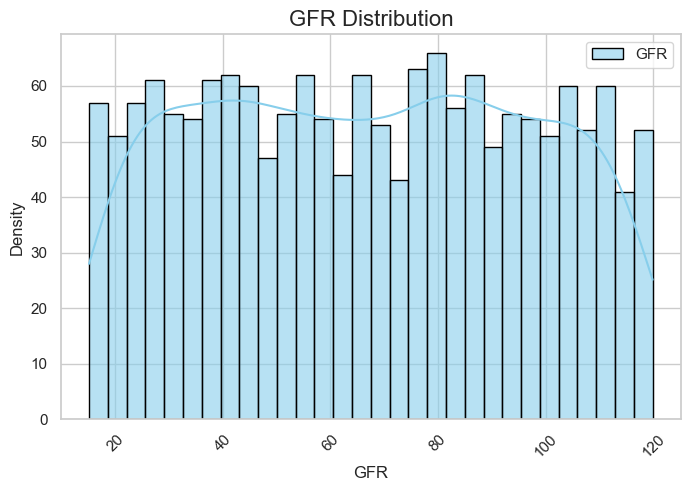

In [11]:
# Mengatur style untuk plot
sns.set(style="whitegrid")

# Buat figure dan axes
plt.figure(figsize=(8, 5))

# Plot histogram dengan overlay KDE untuk kolom 'GFR'
sns.histplot(data['GFR'].dropna(), color='skyblue', label='GFR', kde=True, bins=30, edgecolor='black', alpha=0.6)
plt.title('GFR Distribution', fontsize=16)
plt.ylabel('Density', fontsize=12)
plt.xlabel('GFR', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

##### <u>Penjelasan : </u>

- Data distribusi yang paling banyak muncul berada di range 78 - 88

---

#### Menampilkan distribusi Serum Creatinine dalam dataset

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


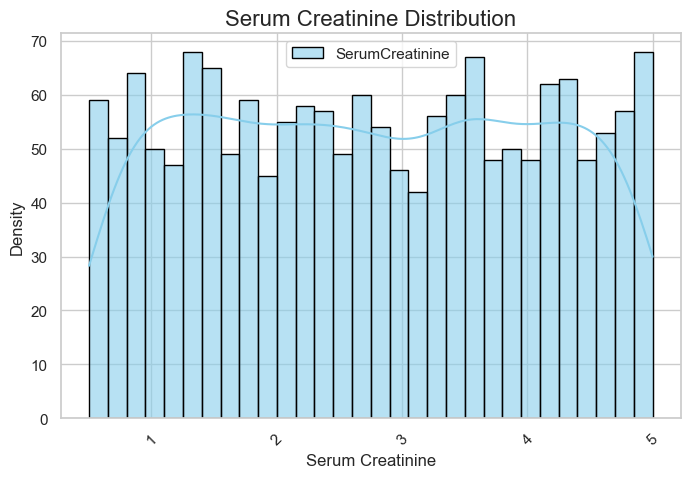

In [12]:
# Mengatur style plot
sns.set(style="whitegrid")

# Buat figure & axes
plt.figure(figsize=(8, 5))

# Plot histogram dengan overlay KDE untuk kolom 'SerumCreatinine'
sns.histplot(data['SerumCreatinine'].dropna(), color='skyblue', label='SerumCreatinine', kde=True, bins=30, edgecolor='black', alpha=0.6)
plt.title('Serum Creatinine Distribution', fontsize=16)
plt.ylabel('Density', fontsize=12)
plt.xlabel('Serum Creatinine', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

##### <u>Penjelasan : </u>

- Data distribusi yang paling banyak muncul berada di range 3.2 - 3.6

---

#### Menampilkan distribusi Protein In Urine dalam dataset

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


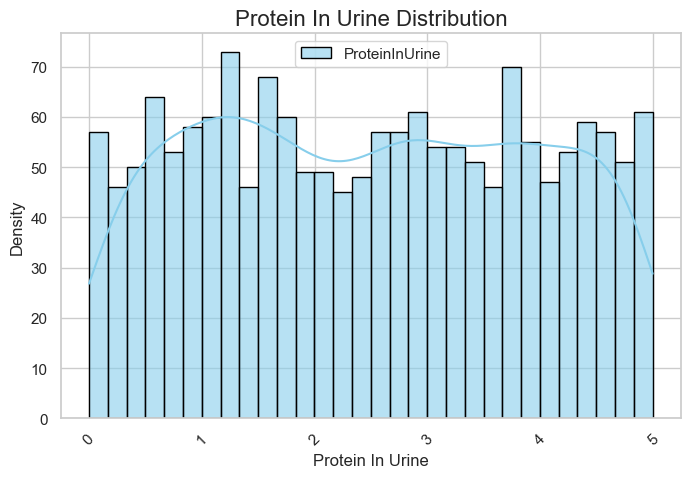

In [13]:
# Mengatur Style Plot
sns.set(style="whitegrid")

# Buat figure & axes
plt.figure(figsize=(8, 5))

# Plot histogram dengan overlay KDE untuk kolom 'ProteinInUrine'
sns.histplot(data['ProteinInUrine'].dropna(), color='skyblue', label='ProteinInUrine', kde=True, bins=30, edgecolor='black', alpha=0.6)
plt.title('Protein In Urine Distribution', fontsize=16)
plt.ylabel('Density', fontsize=12)
plt.xlabel('Protein In Urine', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

##### <u>Penjelasan : </u>

- Data distribusi yang paling banyak muncul berada di range 1 - 1.5

---

#### Menampilkan distribusi ACR dalam dataset

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


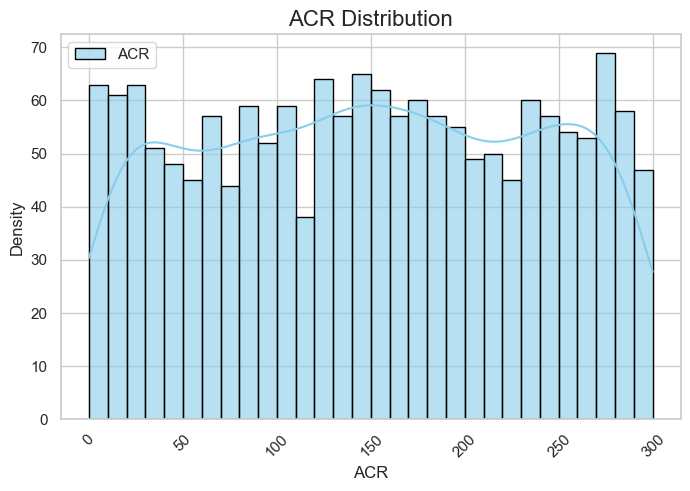

In [14]:
# Style Plot
sns.set(style="whitegrid")

# Buat figure & axes
plt.figure(figsize=(8, 5))

# Plot histogram dengan overlay KDE untuk kolom 'ACR'
sns.histplot(data['ACR'].dropna(), color='skyblue', label='ACR', kde=True, bins=30, edgecolor='black', alpha=0.6)
plt.title('ACR Distribution', fontsize=16)
plt.ylabel('Density', fontsize=12)
plt.xlabel('ACR', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

##### <u>Penjelasan : </u>

- Data distribusi yang paling banyak muncul berada di range 0 - 30

---

#### Menampilkan distribusi BUN Levels dalam dataset

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


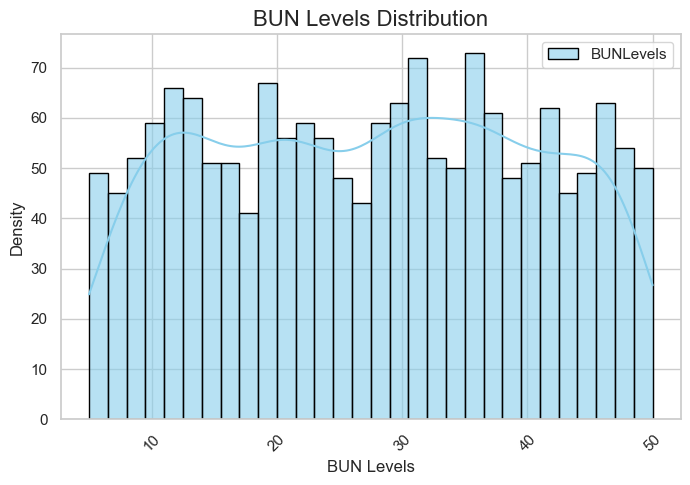

In [15]:
# Style Plot
sns.set(style="whitegrid")

# Membuat figure & axes
plt.figure(figsize=(8, 5))

# Plot histogram dengan overlay KDE untuk kolom 'BUNLevels'
sns.histplot(data['BUNLevels'].dropna(), color='skyblue', label='BUNLevels', kde=True, bins=30, edgecolor='black', alpha=0.6)
plt.title('BUN Levels Distribution', fontsize=16)
plt.ylabel('Density', fontsize=12)
plt.xlabel('BUN Levels', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

##### <u>Penjelasan : </u>

- Data distribusi yang paling banyak muncul berada di range 27.5 - 32

---

#### Menampilkan kolom diagnosis dalam dataset

Diagnosis
1    1524
0     135
Name: count, dtype: int64


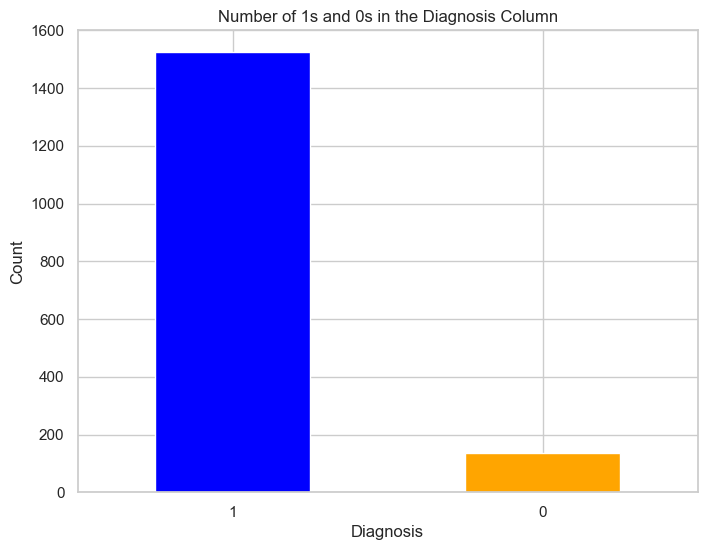

In [16]:
# Kelas Diagnosis
print(data['Diagnosis'].value_counts())

# Hitung jumlah angka 1 dan 0 di kolom Diagnosis
diagnosis_counts = data['Diagnosis'].value_counts()

# Plot Grafik Batang
plt.figure(figsize=(8, 6))
diagnosis_counts.plot(kind='bar', color=['blue', 'orange'])
plt.title('Number of 1s and 0s in the Diagnosis Column')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(ticks=[1, 0], labels=['0', '1'], rotation=0)
plt.show()

##### <u>Keterangan : </u>
0 = Non CKD (Bukan Penderita)

1 = CKD (Penderita)

Count = Jumlah Orang

##### <u> Penjelasan : </u>
- Dari output yang dihasilkan menunjukkan bahwa jumlah yang penderita lebih banyak daripada yang bukan penderita


---

#### Install Imbalance - Learn

In [17]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


##### <u> Penjelasan: </u>

- Imbalance learn (SMOTE) digunakan untuk mengimbangkan jumlah data antara CKD dengan Non-CKD

- Data diseimbangkan. Karena jika tidak diseimbangkan, maka hasil prediksi akan cenderung lebih condong ke data yang lebih banyak daripada yang lebih sedikit

#### Import Library Imbalance - Learn SMOTE

In [18]:
from imblearn.over_sampling	import	SMOTE

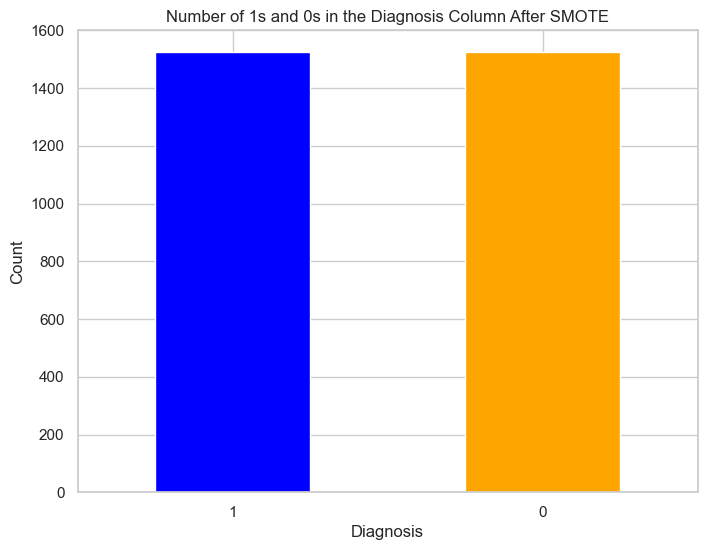

Diagnosis
1    1524
0    1524
Name: count, dtype: int64


In [19]:
# Separate features and target 
X = data.drop(['Diagnosis'], axis=1) 
y = data['Diagnosis'] 

# Menerapkan SMOTE 
smote = SMOTE(random_state=42) 
X_resampled, y_resampled = smote.fit_resample(X, y) 

# Gabungkan fitur dan target yang telah di-resampling ke dalam DataFrame baru
data_resampled = pd.DataFrame(X_resampled, columns=X.columns) 
data_resampled['Diagnosis'] = y_resampled 

# Hitung jumlah 1 dan 0 di kolom Diagnosis setelah resampling 
diagnosis_counts_resampled = data_resampled['Diagnosis'].value_counts() 

# Buat grafik batang untuk data resampel
plt.figure(figsize=(8, 6))
diagnosis_counts_resampled.plot(kind='bar', color=['blue', 'orange']) 
plt.title('Number of 1s and 0s in the Diagnosis Column After SMOTE') 
plt.xlabel('Diagnosis') 
plt.ylabel('Count')
plt.xticks(ticks=[1, 0], labels=['0', '1'],	rotation=0)
plt.show()

# Cetak jumlah setiap kelas setelah resampling
print(diagnosis_counts_resampled)


##### <u>Keterangan : </u>
0 = Non CKD (Bukan Penderita)

1 = CKD (Penderita)

##### <u> Penjelasan: </u>

- Output visual diatas merupakan tampilan setelah data CKD dan Non-CKD diseimbangkan menggunakan Imbalance - Learn

---

#### Pair Plotting of Selected Features 4 Serum

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

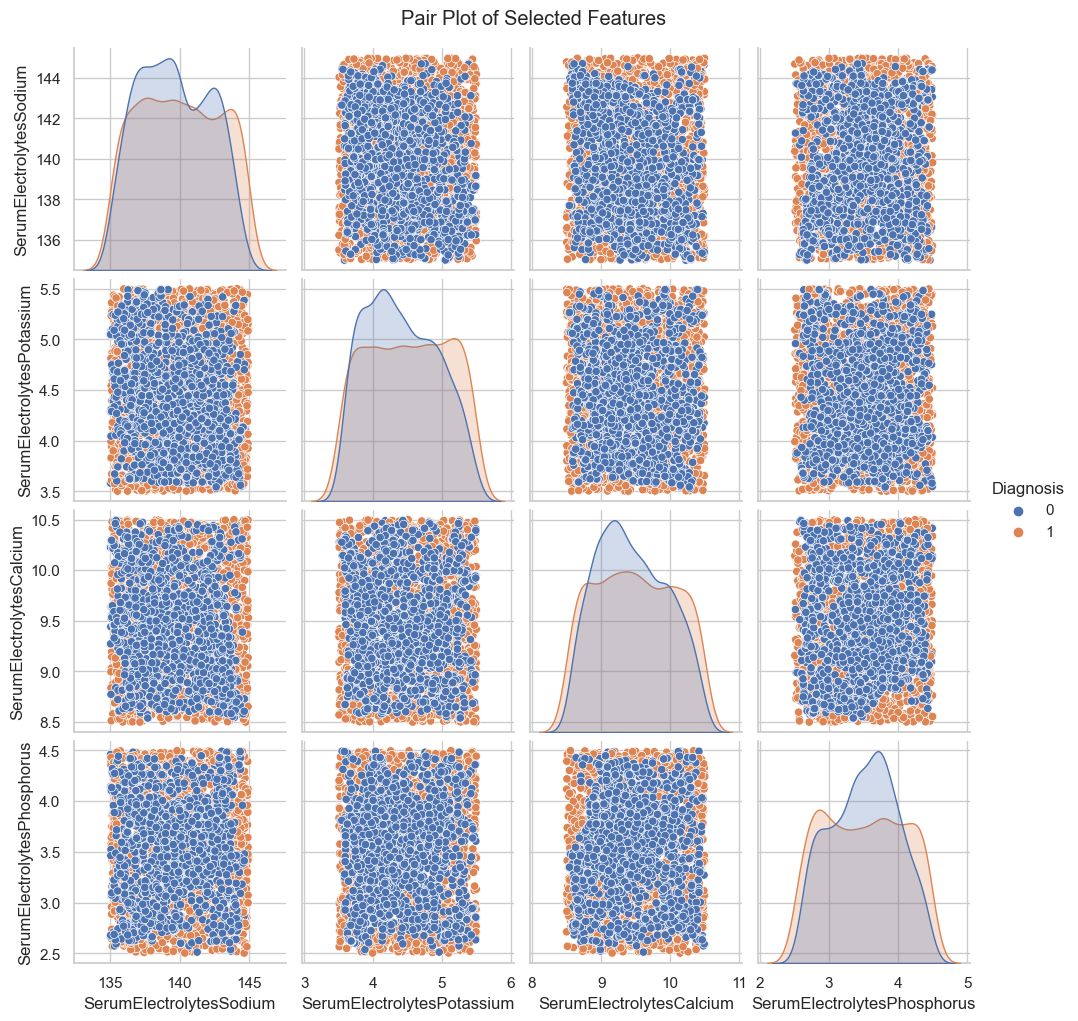

In [20]:
# Define selected features
selected_features = ['SerumElectrolytesSodium', 'SerumElectrolytesPotassium', 
                     'SerumElectrolytesCalcium', 'SerumElectrolytesPhosphorus']

# Buat plot berpasangan dengan KDE untuk plot diagonal dan rona berdasarkan 'Diagnosis'
sns.pairplot(data_resampled[selected_features + ['Diagnosis']], hue='Diagnosis', diag_kind='kde')

# Tambahkan judul dengan posisi yang disesuaikan
plt.suptitle('Pair Plot of Selected Features', y=1.02)

# menampilkan plot
plt.show()

##### <u>Keterangan : </u>
0 = Non CKD (Bukan Penderita)

1 = CKD (Penderita)

##### <u> Penjelasan: </u>

- Pair plot di gambar memperlihatkan hubungan antara empat fitur serum elektrolit (Sodium, Potassium, Calcium, Phosphorus) pada pasien dengan dan tanpa CKD (Chronic Kidney Disease). Berikut penjelasannya:

1. Scatter plots (titik-titik di luar diagonal) menunjukkan hubungan antar fitur. Tidak ada pola yang jelas yang bisa langsung membedakan pasien CKD (oranye) dan non-CKD (biru) dari kombinasi dua fitur elektrolit serum.

2. Diagonal plots menampilkan distribusi masing-masing fitur:
   - Sodium dan calcium menunjukkan distribusi yang mirip untuk CKD dan non-CKD.
   - Potassium dan phosphorus menunjukkan sedikit perbedaan antara pasien CKD dan non-CKD, terutama pada rentang yang lebih rendah atau lebih tinggi.

---

#### Distribusi BMI Berdasarkan Status Diagnosis

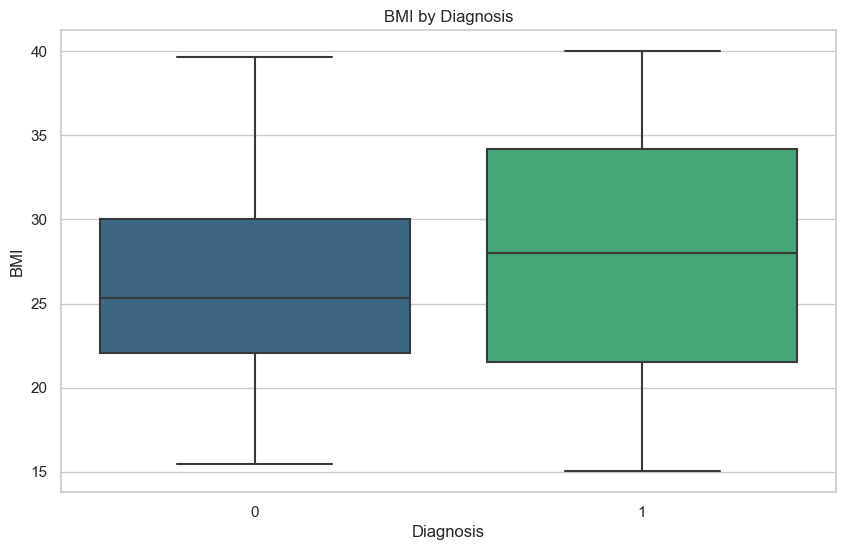

In [21]:
# Diagram kotak BMI berdasarkan Diagnosis menggunakan data resampled
plt.figure(figsize=(10, 6)) 
sns.boxplot(x='Diagnosis', y='BMI', data=data_resampled, palette='viridis') 
plt.title('BMI by Diagnosis') 
plt.xlabel('Diagnosis') 
plt.ylabel('BMI') 
plt.show()

##### <u>Keterangan : </u>
0 = Non CKD (Bukan Penderita)

1 = CKD (Penderita)

##### <u> Penjelasan: </u>
- Kelompok penderita CKD memiliki nilai BMI median yang sedikit lebih tinggi dibandingkan dengan kelompok non CKD. 
- Rentang BMI pada kelompok penderita CKD lebih lebar, menunjukkan variasi yang lebih besar. 
- Whisker menunjukkan nilai minimum dan maksimum, tanpa terlihat adanya outlier. Hal ini menunjukkan bahwa variasi BMI mungkin berkorelasi dengan status diagnosis.

---

#### Menampilkan Distribusi Umur Menggunakan Histogram

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


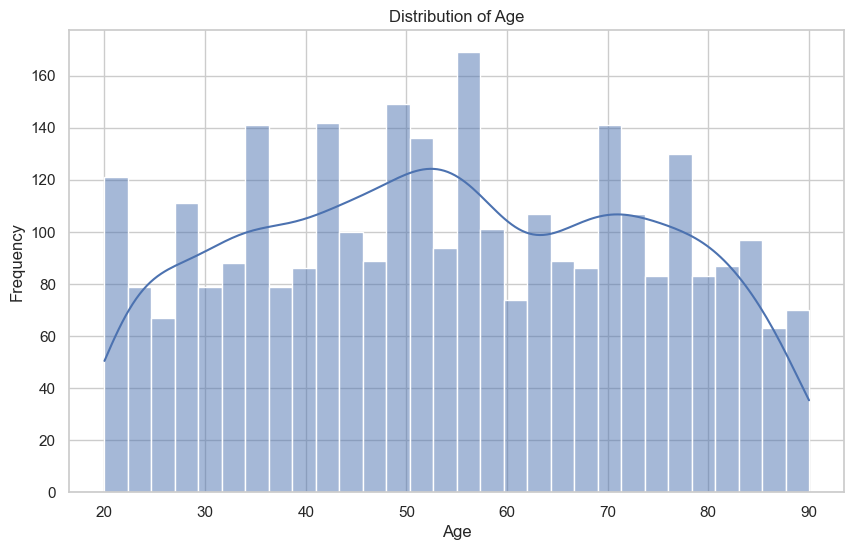

In [22]:
plt.figure(figsize=(10, 6)) 
sns.histplot(data_resampled['Age'], bins=30, kde=True) 
plt.title('Distribution of Age') 
plt.xlabel('Age') 
plt.ylabel('Frequency') 
plt.show()

##### <u> Penjelasan: </u>

- Range umur dari pasien yang didapatkan dari dataset berusia 20 - 90



---

#### Menampilkan kelompok etnis dan jumlahnya yang termasuk didalam dataset Menggunakan Grafik Batang

Ethnicity
0    974
1    349
2    174
3    162
Name: count, dtype: int64


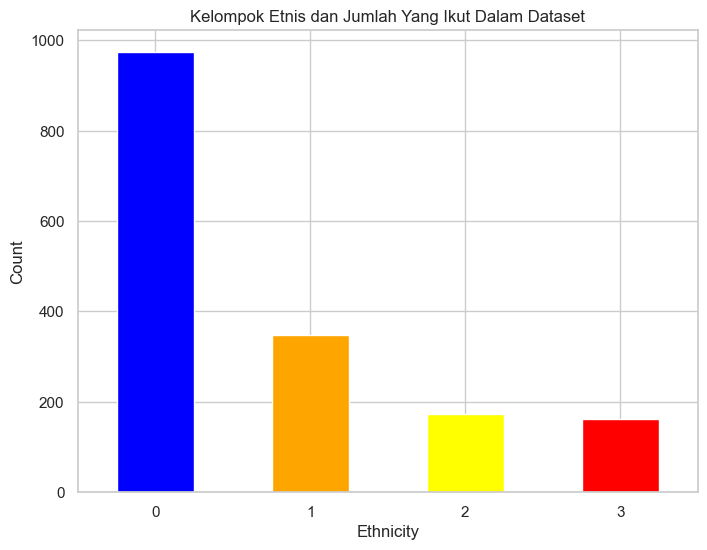

In [23]:
# Kelas Etnis
print(data['Ethnicity'].value_counts())

# Hitung jumlah angka 0, 1, 2 dan 3 pada kolom Etnis
ethnicity_counts = data['Ethnicity'].value_counts()

# Membuat Diagram Batang
plt.figure(figsize=(8,	6))
ethnicity_counts.plot(kind='bar', color=['blue', 'orange', 'yellow', 'red'])
plt.title('Kelompok Etnis dan Jumlah Yang Ikut Dalam Dataset')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3], labels=['0', '1', '2', '3'],	rotation=0)
plt.show()

##### <u> Keterangan : </u>
0. Etnis Caucasian = 974

1. Etnis African American = 349 

2. Etnis Asian = 174
 
3. Etnis lain = 162

##### <u> Penjelasan : </u>

- Dari output yang dikeluarkan dapat dilihat bahwa etnis kaukasia memiliki jumlah terbanyak yang ada dalam dataset disusul dengan etnis lain

---

#### Menampilkan jumlah kolom dan baris dari data yang sudah di drop


In [24]:
data.shape

(1659, 15)

##### <u>Penjelasan :</u>

Dari output yang dikeluarkan dapat diketahui jumlah kolom dan baris dari data setelah di drop 
- Jumlah Baris sebanyak 1659

- Jumlah Kolom sebanyak 15

---

#### Menampilkan Korelasi Matrix


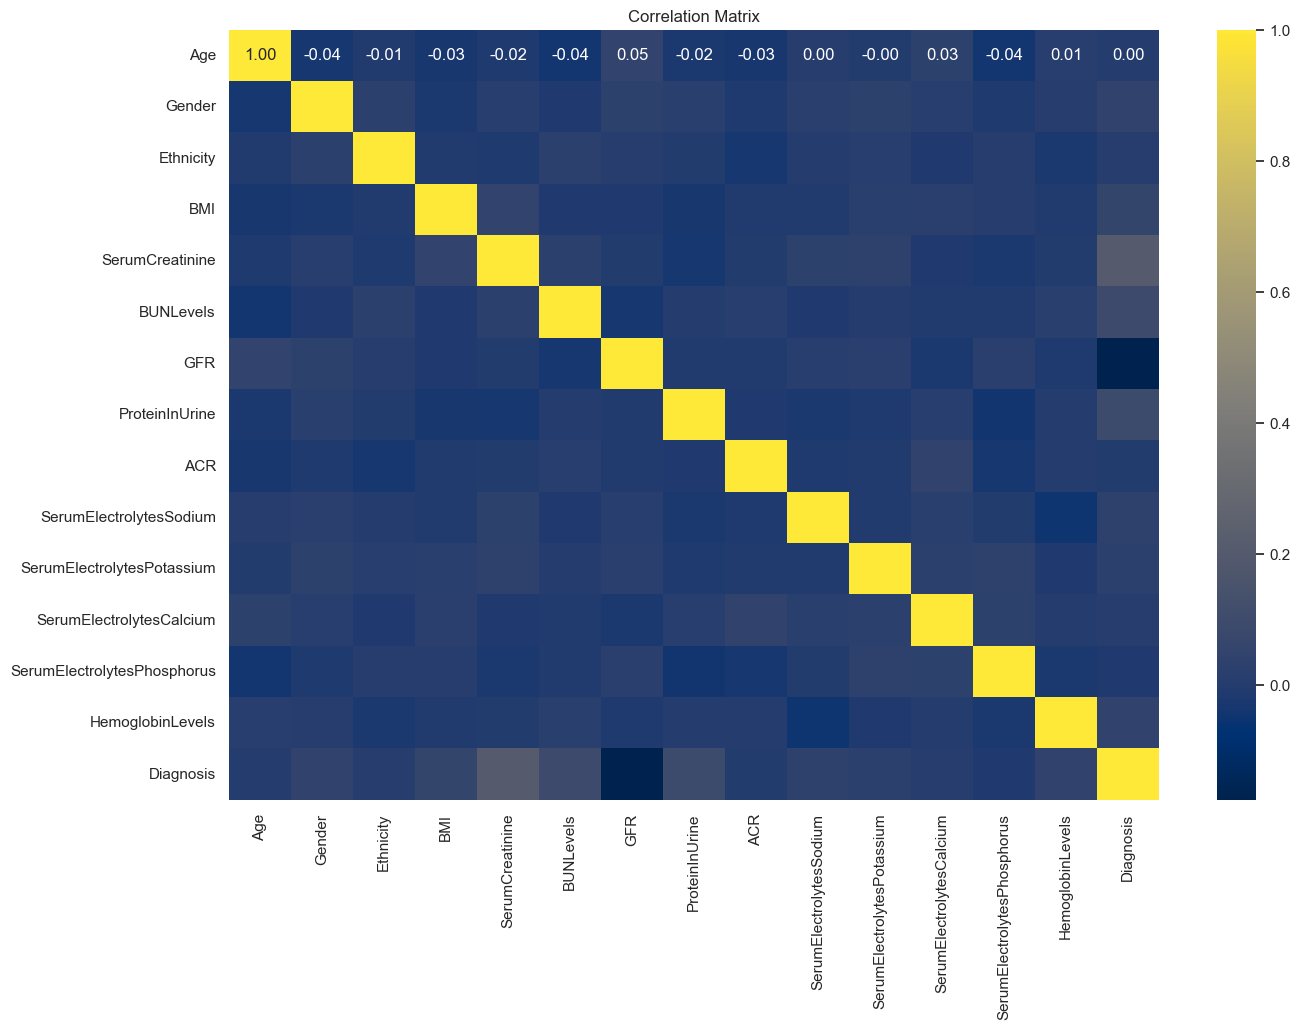

In [25]:
# matriks korelasi dan peta panas akan membantu mengidentifikasi
# fitur yang sangat berkorelasi dengan variabel target - Diagno

correlation_matrix = data.corr() 

# Membuat heatmap
plt.figure(figsize=(15, 10)) 
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='cividis') 
plt.title('Correlation Matrix') 
plt.show()

##### <u>Penjelasan</u>

- Hubungan setiap fitur dengan fitur lain

- Hubungan / korelasi antar fitur yang berwarna kuning, mengapa tertinggi ? Karena menghitung antar fitur yang sama sehingga menghasilkan angka tertinggi yaitu 1.00.

- Disini kita dapat melihat hubungan / korelasi antar fitur yang kuat diluar korelasi antar fitur yang sama, berada pada antar fitur SerumCreatinine dengan Diagnosis dengan angka mencapai 0.20 yang berwarna abu-abu cerah

- Sedangkan kita dapat melihat bahwa hubungan / korelasi antar fitur yang terlemah, berada pada antar fitur Diagnosis dan GFR dengan angka mencapai -0.18 dengan warna kotak tergelap

---

#### Menampilkan jumlah kolom dan baris dari data yang sudah di resample


In [26]:
data_resampled.shape

(3048, 15)

##### <u>Penjelasan :</u>

Dari output yang dikeluarkan dapat diketahui bahwa jumlah baris dan kolom setelah diresample
- Jumlah Baris sebanyak 1659

- Jumlah Kolom sebanyak 54

---

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Buat kolom target berdasarkan parameter klinis
def classify_ckd(row):
    if row['GFR'] >= 100 and row['ACR'] < 30 and row['BUNLevels'] >= 7 and row['BUNLevels'] <= 20 and row['SerumCreatinine'] >= 0.5 and row['SerumCreatinine'] <= 1.2:
        return 'non-CKD'
    elif row['GFR'] >= 60 and row['ACR'] >= 30 and row['ACR'] <= 200 and row['BUNLevels'] > 20 and row['BUNLevels'] <= 35 and row['SerumCreatinine'] > 1.2 and row['SerumCreatinine'] <= 3.5:
        return 'CKD awal'
    elif row['GFR'] <= 59 and row['ACR'] > 200 and row['BUNLevels'] > 35 and row['SerumCreatinine'] > 3.5:
        return 'CKD akhir'
    else:
        return np.nan

data['CKD_stage'] = data.apply(classify_ckd, axis=1)
data = data.dropna(subset=['CKD_stage'])  # Drop rows with NaN in CKD_stage

In [6]:
# Encode target labels
target_mapping = {'non-CKD': 0, 'CKD awal': 1, 'CKD akhir': 2}
data['CKD_stage_encoded'] = data['CKD_stage'].map(target_mapping)

In [7]:
# Pisahkan fitur dan target
X = data[['GFR', 'ACR', 'BUNLevels', 'SerumCreatinine']]  # Parameter klinis
y = data['CKD_stage_encoded']

In [8]:
# Bagi data menjadi data pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Bangun model Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
# Prediksi pada data pengujian
y_pred = rf_model.predict(X_test)

In [11]:
# Filter dataset to include only the selected features and target
selected_features = ['GFR', 'ACR']  # Replace with your desired features
X = data[selected_features].values
y = data['CKD_stage_encoded'].values  # Target column with encoded CKD stages

# Train a Random Forest
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X, y)

RandomForestClassifier(n_estimators=10, random_state=42)

In [12]:
# Create a grid for plotting decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

In [ ]:
# Plot decision boundaries for each tree
plt.figure(figsize=(15, 10))
for i, tree in enumerate(rf_model.estimators_):
    plt.subplot(3, 4, i + 1)
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.viridis)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.viridis)
    plt.title(f"Tree {i + 1} Decision Boundary")

In [ ]:
# Plot the aggregate Random Forest decision boundary
plt.figure(figsize=(8, 6))
Z = rf_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.viridis)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.viridis)
plt.title("Random Forest Decision Boundary")
plt.xlabel(selected_features[0])
plt.ylabel(selected_features[1])
plt.show()

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

     non-CKD       0.00      0.00      0.00         0
    CKD awal       1.00      1.00      1.00        17
   CKD akhir       1.00      1.00      1.00         6

   micro avg       1.00      1.00      1.00        23
   macro avg       0.67      0.67      0.67        23
weighted avg       1.00      1.00      1.00        23



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/

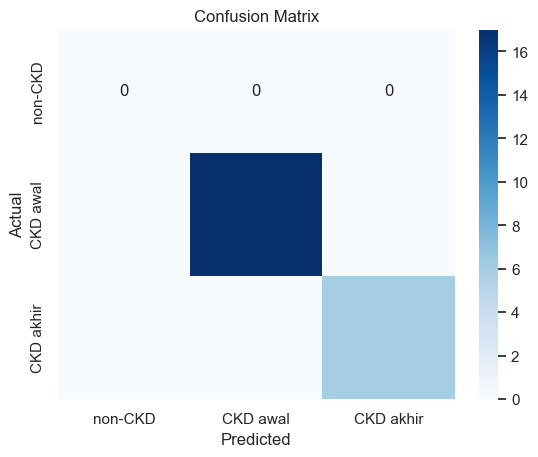

In [42]:
# Evaluasi performa
labels = list(target_mapping.values())  # [0, 1, 2] sesuai urutan target_mapping
target_names = list(target_mapping.keys())  # ['non-CKD', 'CKD awal', 'CKD akhir']

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, labels=labels, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [25]:
# Your codes are here (replace the following codes)
import time
time.sleep(10)

In [26]:
!jupyter nbconvert --to html "./UTS2024_IF540L_KelasAL_Kelompok_1.ipynb" --output-dir="./"

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot

Jupyter command `jupyter-nbconvert` not found.


### Next step:
* convert the generated html file to PDF using the online tool: https://www.sejda.com/html-to-pdf
* choose the following settings:
    * Page size: One long page
    * Page Orientation: auto
    * Use print stylesheet
* Submit your ipython notebook and PDF files

Markdown basics https://markdown-guide.readthedocs.io/en/latest/basics.html#